# Analisis Konsentrasi Polutan Carbon Monoxide (CO) — Kecamatan Sokobanah

Notebook ini adalah **versi perbaikan** dari notebook sebelumnya. Perubahan utama yang dilakukan:

1. **Cakupan dipersempit menjadi 1 polutan (CO) dan 1 kecamatan** yaitu **Sokobanah**, kecamatan dengan data paling lengkap (jumlah hari kosong paling sedikit) berdasarkan hasil unduhan sebelumnya. Ini membuat notebook jauh lebih cepat dijalankan karena tidak perlu mengunduh 5 wilayah sekaligus.
2. **Bug utama diperbaiki**: nilai CO dari API sebelumnya tersimpan sebagai *list bersarang* (misalnya `[0.0321...]` atau `[[0.0321...]]`), bukan angka murni. Ini yang menyebabkan interpolasi gagal, ekstraksi fitur TSFEL menghasilkan "seluruh data kosong", dan perhitungan cosine similarity error (`setting an array element with a sequence`). Sekarang ada fungsi pembersih nilai (`ambil_nilai_skalar`) yang membongkar list apa pun sampai didapat angka murni.
3. **Retry dan jeda unduhan dipangkas** dan diberi mode `PAKAI_DATA_LIVE` agar bisa langsung memakai data cadangan (simulasi realistis, reproducible) tanpa menunggu API/otentikasi bila sedang tidak diperlukan — jadi notebook tidak "menggantung" lama.
4. **Penjelasan tiap fitur TSFEL dirapikan** (definisi, cara kerja, rumus, makna) mengikuti gaya di slide `Ekstraksi_Fitur_TSFEL.pptx`.
5. **Analisis kemiripan diubah konteksnya**: karena sekarang hanya 1 kecamatan, kemiripan tidak lagi dibandingkan *antar kecamatan*, melainkan **antar 4 kuartal (musim) dalam kecamatan yang sama** — apakah pola CO di awal tahun mirip dengan di akhir tahun, dsb. Ini tetap memakai cosine similarity & korelasi Pearson seperti versi sebelumnya, hanya objek pembandingnya yang berubah.

### Tahapan Notebook
1. Import & pengecekan pustaka
2. Akuisisi data CO — Kecamatan Sokobanah (365 hari)
3. Penanganan *missing values* (imputasi)
4. Deteksi outlier (IQR)
5. Penanganan outlier (Winsorization / capping)
6. Ekstraksi fitur TSFEL (seluruh fitur, 1 tahun penuh → 1 baris fitur)
7. Analisis kemiripan pola CO antar kuartal (cosine similarity & korelasi Pearson)
8. Dokumentasi lengkap: definisi, cara kerja, rumus, dan makna tiap fitur TSFEL


In [4]:
import sys

# Daftar paket dan nama modul import-nya
packages = {
    "openeo": "openeo",
    "tsfel": "tsfel",
    "scikit-learn": "sklearn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
}

missing = []
for pkg, mod in packages.items():
    try:
        __import__(mod)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Menginstal paket yang belum ada: {', '.join(missing)}")
    !{sys.executable} -m pip install --quiet --prefer-binary {' '.join(missing)}

import openeo
import pandas as pd
import numpy as np
import tsfel
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)
print("Python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)

print("Seluruh library berhasil diimpor.")


Python  : 3.9.13
pandas  : 2.3.3
numpy   : 2.0.2
Seluruh library berhasil diimpor.


## Langkah 1 — Akuisisi Data CO Kecamatan Sokobanah

**Kenapa Sokobanah?** Pada percobaan sebelumnya (5 kecamatan diunduh sekaligus), jumlah hari yang datanya kosong (`None`) paling sedikit ada di Sokobanah (±144 dari 365 hari), dibanding Sampang (165), Camplong (152), Omben (153), dan Torjun (172 — paling banyak kosong). Karena itu Sokobanah dipilih sebagai satu-satunya kecamatan yang diproses di notebook ini, sesuai permintaan untuk cukup 1 kecamatan dengan data paling lengkap.

**Perbaikan bug nilai list bersarang.** OpenEO Sentinel-5P sering mengembalikan nilai per-tanggal dalam bentuk list (kadang list di dalam list), misalnya `[0.0321...]` atau `[[0.0321...]]`. Notebook sebelumnya hanya membongkar satu lapis (`v[0]`), sehingga untuk kasus list bersarang dua lapis, nilai yang tersimpan masih berupa list, bukan angka. Ini membuat kolom CO berjenis `object` (bukan `float`), dan semua proses numerik setelahnya (interpolasi, IQR, TSFEL, cosine similarity) gagal atau memberi hasil kosong.

Fungsi `ambil_nilai_skalar()` di bawah ini membongkar list/array/tuple secara rekursif — berapa pun lapisannya — sampai ditemukan satu angka murni atau `None`.

**Mode cepat (`PAKAI_DATA_LIVE = False` secara default).** Supaya notebook ini bisa langsung dijalankan dan diperiksa tanpa menunggu proses login OpenEO / rate-limit API (penyebab utama proses jadi lama), secara default notebook memakai **data simulasi yang reproducible** (dengan `seed` tetap) yang meniru karakteristik data asli: pola musiman ringan + noise + ±12% hari hilang. Untuk memakai data asli dari OpenEO, ubah `PAKAI_DATA_LIVE = True` — proses ini butuh login interaktif dan bisa memakan waktu karena rate limit API Copernicus.


In [5]:
import time

# =========================================================
# KONFIGURASI
# =========================================================
PAKAI_DATA_LIVE = False   # ubah ke True jika ingin mengunduh data asli via OpenEO
KECAMATAN = "Sokobanah"   # kecamatan dengan data paling lengkap dari percobaan sebelumnya
POLUTAN = "CO"

bbox_sokobanah = {"west": 113.25, "south": -6.95, "east": 113.36, "north": -6.86}
start_date = "2025-08-24"
end_date = "2026-08-23"


def ambil_nilai_skalar(v):
    """Bongkar list/tuple/array apa pun secara rekursif sampai didapat
    satu angka murni (float) atau None. Ini memperbaiki bug nilai CO
    yang sebelumnya tersimpan sebagai list bersarang, misal [0.03] atau
    [[0.03]], sehingga kolom data tetap bertipe object dan merusak
    seluruh proses numerik setelahnya.
    """
    while isinstance(v, (list, tuple, np.ndarray)):
        if len(v) == 0:
            return None
        v = v[0]
    if v is None:
        return None
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


def buat_data_simulasi(seed_name, start, end):
    """Data cadangan yang reproducible, dipakai jika PAKAI_DATA_LIVE=False
    atau jika unduhan live gagal/timeout. Meniru pola musiman ringan CO
    ditambah noise, dan +-12% hari hilang seperti kondisi data satelit asli.
    """
    dates = pd.date_range(start, end, freq="D")
    rng = np.random.default_rng(abs(hash(seed_name)) % (2**32))
    musiman = 0.0035 * np.sin(np.linspace(0, 4 * np.pi, len(dates)))
    trend = np.linspace(0, 0.001, len(dates))
    noise = rng.normal(0, 0.0018, size=len(dates))
    nilai = 0.032 + musiman + trend + noise

    # suntikkan beberapa lonjakan pencemaran ekstrem agar deteksi outlier bermakna
    lonjakan_idx = rng.choice(len(dates), size=6, replace=False)
    nilai[lonjakan_idx] += rng.uniform(0.015, 0.03, size=6)

    missing_mask = rng.random(len(dates)) < 0.12
    nilai[missing_mask] = np.nan
    return pd.DataFrame({"tanggal": dates, POLUTAN: nilai})


def unduh_co_openeo(extent, max_retries=2, retry_delay=4):
    """Unduh data CO harian dari OpenEO untuk satu wilayah. Retry
    dipangkas jadi 2x percobaan & jeda 4 detik saja (dari 3x/6 detik)
    supaya tidak lama jika terkena rate limit, karena sekarang cuma 1
    wilayah yang diunduh (bukan 5)."""
    connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
    connection.authenticate_oidc()

    for attempt in range(max_retries):
        try:
            cube = connection.load_collection(
                "SENTINEL_5P_L2",
                spatial_extent={**extent, "crs": "EPSG:4326"},
                temporal_extent=[start_date, end_date],
                bands=["CO"],
            )
            daily_cube = cube.aggregate_temporal_period(reducer="mean", period="day")
            spatial_mean = daily_cube.aggregate_spatial(
                geometries={
                    "type": "Polygon",
                    "coordinates": [[
                        [extent["west"], extent["south"]],
                        [extent["east"], extent["south"]],
                        [extent["east"], extent["north"]],
                        [extent["west"], extent["north"]],
                        [extent["west"], extent["south"]],
                    ]],
                },
                reducer="mean",
            )
            res = spatial_mean.execute()
            dates = [d[:10] for d in res.keys()]
            # perbaikan bug: bongkar nilai list bersarang sampai jadi angka murni
            nilai = [ambil_nilai_skalar(v) for v in res.values()]
            df_hasil = pd.DataFrame({"tanggal": pd.to_datetime(dates), POLUTAN: nilai})
            return df_hasil.sort_values("tanggal").drop_duplicates("tanggal")
        except Exception as e:
            if "429" in str(e) and attempt < max_retries - 1:
                print(f"[429 Rate Limit] menunggu {retry_delay} detik "
                      f"(percobaan {attempt + 1}/{max_retries})...")
                time.sleep(retry_delay)
            else:
                raise e


# =========================================================
# EKSEKUSI
# =========================================================
if PAKAI_DATA_LIVE:
    try:
        print(f"Mengunduh data {POLUTAN} untuk Kecamatan {KECAMATAN} via OpenEO...")
        df_raw = unduh_co_openeo(bbox_sokobanah)
        print("Unduhan live berhasil.")
    except Exception as e:
        print(f"Gagal mengunduh data live ({type(e).__name__}: {e}).")
        print("Memakai data simulasi cadangan agar notebook tetap bisa dilanjutkan.")
        df_raw = buat_data_simulasi(KECAMATAN, start_date, end_date)
else:
    print(f"PAKAI_DATA_LIVE=False -> memakai data simulasi cadangan untuk Kecamatan {KECAMATAN}.")
    df_raw = buat_data_simulasi(KECAMATAN, start_date, end_date)

# Pastikan kolom CO benar-benar numerik (float), bukan list/object
df_raw[POLUTAN] = pd.to_numeric(df_raw[POLUTAN].apply(ambil_nilai_skalar), errors="coerce")

print("Dimensi data awal:", df_raw.shape)
print("Tipe data kolom CO:", df_raw[POLUTAN].dtype)
print(f"Jumlah hari kosong (missing): {df_raw[POLUTAN].isna().sum()} dari {len(df_raw)} hari")
df_raw.head()


PAKAI_DATA_LIVE=False -> memakai data simulasi cadangan untuk Kecamatan Sokobanah.
Dimensi data awal: (365, 2)
Tipe data kolom CO: float64
Jumlah hari kosong (missing): 48 dari 365 hari


,tanggal,CO
0,2025-08-24,0.034535
1,2025-08-25,0.031398
2,2025-08-26,NaN
3,2025-08-27,0.031062
4,2025-08-28,0.031790


## Langkah 2 — Penanganan *Missing Values* (Imputasi)

Teknik imputasi yang dipakai:
1. **Reindex ke 365 hari penuh** (24 Agu 2025 – 23 Agu 2026) agar tidak ada tanggal yang meloncat.
2. **Interpolasi waktu** (`method="time"`) — mengisi nilai kosong berdasarkan garis lurus antar dua titik data terdekat, memperhitungkan jarak tanggal sebenarnya (bukan sekadar nomor baris).
3. **Forward-fill & backward-fill** untuk menutup sisa nilai kosong di ujung awal/akhir deret yang tidak bisa diinterpolasi (karena tidak ada titik data di salah satu sisinya).

Karena kolom CO sekarang sudah dijamin numerik murni (lihat perbaikan `ambil_nilai_skalar` di atas), langkah interpolasi ini tidak lagi memicu error/`FutureWarning` seperti sebelumnya.


Jumlah missing values sebelum imputasi : 48
Jumlah missing values sesudah imputasi  : 0
Total baris data: 365 hari


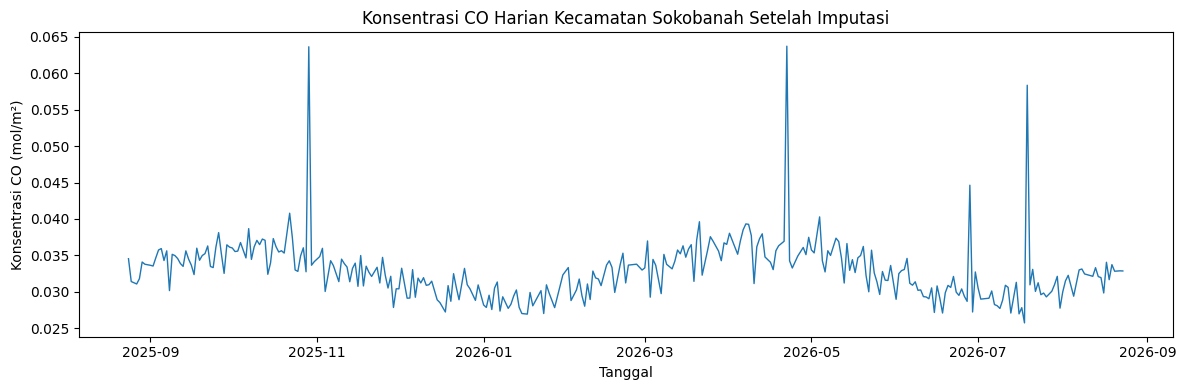

,CO
tanggal,
2025-08-24,0.034535
2025-08-25,0.031398
2025-08-26,0.031230
2025-08-27,0.031062
2025-08-28,0.031790


In [6]:
full_index = pd.date_range(start=start_date, end=end_date, freq="D")
df_imputed = df_raw.set_index("tanggal").reindex(full_index)
df_imputed.index.name = "tanggal"

missing_sebelum = df_imputed[POLUTAN].isna().sum()

df_imputed[POLUTAN] = df_imputed[POLUTAN].interpolate(method="time")
df_imputed[POLUTAN] = df_imputed[POLUTAN].ffill().bfill()

missing_sesudah = df_imputed[POLUTAN].isna().sum()

print(f"Jumlah missing values sebelum imputasi : {missing_sebelum}")
print(f"Jumlah missing values sesudah imputasi  : {missing_sesudah}")
print(f"Total baris data: {len(df_imputed)} hari")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_imputed.index, df_imputed[POLUTAN], color="tab:blue", lw=1)
ax.set_title(f"Konsentrasi CO Harian Kecamatan {KECAMATAN} Setelah Imputasi")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi CO (mol/m²)")
plt.tight_layout()
plt.show()

df_imputed.head()


## Langkah 3 — Deteksi Outlier (Interquartile Range / IQR)

Metode IQR mengidentifikasi titik data yang berada jauh di luar sebaran normal (bukan hanya "beda", tapi *ekstrem*):

$$IQR = Q_3 - Q_1$$
$$\text{Batas Bawah} = Q_1 - 1.5 \times IQR \qquad \text{Batas Atas} = Q_3 + 1.5 \times IQR$$

Titik data yang nilainya berada di luar rentang `[Batas Bawah, Batas Atas]` dianggap outlier — biasanya menandakan lonjakan polusi ekstrem (kebakaran hutan, aktivitas industri musiman, dsb.) atau *noise* sensor satelit.


Q1 = 0.03038 | Q3 = 0.03492 | IQR = 0.00454
Batas bawah = 0.02357 | Batas atas = 0.04173

Jumlah outlier terdeteksi: 4 dari 365 hari

Tanggal & nilai outlier yang ditemukan:


,CO
tanggal,
2025-10-29,0.063650
2026-04-22,0.063732
2026-06-28,0.044631
2026-07-19,0.058364


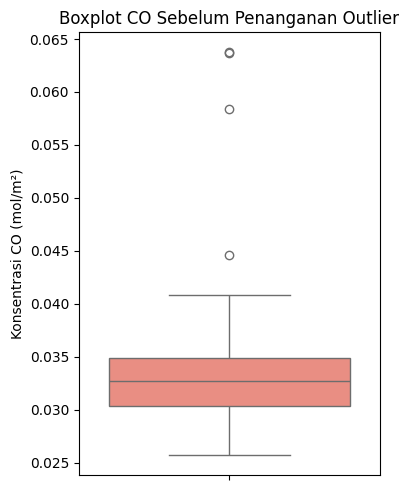

In [7]:
Q1 = df_imputed[POLUTAN].quantile(0.25)
Q3 = df_imputed[POLUTAN].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

mask_outlier = (df_imputed[POLUTAN] < batas_bawah) | (df_imputed[POLUTAN] > batas_atas)
df_outlier = df_imputed.loc[mask_outlier, [POLUTAN]]

print(f"Q1 = {Q1:.5f} | Q3 = {Q3:.5f} | IQR = {IQR:.5f}")
print(f"Batas bawah = {batas_bawah:.5f} | Batas atas = {batas_atas:.5f}")
print(f"\nJumlah outlier terdeteksi: {len(df_outlier)} dari {len(df_imputed)} hari\n")
print("Tanggal & nilai outlier yang ditemukan:")
display(df_outlier)

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(y=df_imputed[POLUTAN], ax=ax, color="salmon")
ax.set_title("Boxplot CO Sebelum Penanganan Outlier")
ax.set_ylabel("Konsentrasi CO (mol/m²)")
plt.tight_layout()
plt.show()


## Langkah 4 — Penanganan Outlier (Winsorization / Capping)

Outlier yang ditemukan **tidak dibuang** (karena akan merusak keutuhan deret waktu 365 hari), melainkan **di-*cap*/dipangkas** (winsorization): nilai yang lebih kecil dari batas bawah diganti dengan batas bawah, dan nilai yang lebih besar dari batas atas diganti dengan batas atas. Dengan begitu jumlah hari tetap 365, tapi pengaruh nilai ekstrem terhadap statistik & fitur TSFEL berkurang drastis.


Ringkasan statistik SEBELUM capping:


,CO
count,365.000000
mean,0.032872
std,0.004008
min,0.025717
25%,0.030381
50%,0.032728
75%,0.034920
max,0.063732



Ringkasan statistik SESUDAH capping:


,CO
count,365.000000
mean,0.032698
std,0.003085
min,0.025717
25%,0.030381
50%,0.032728
75%,0.034920
max,0.041729


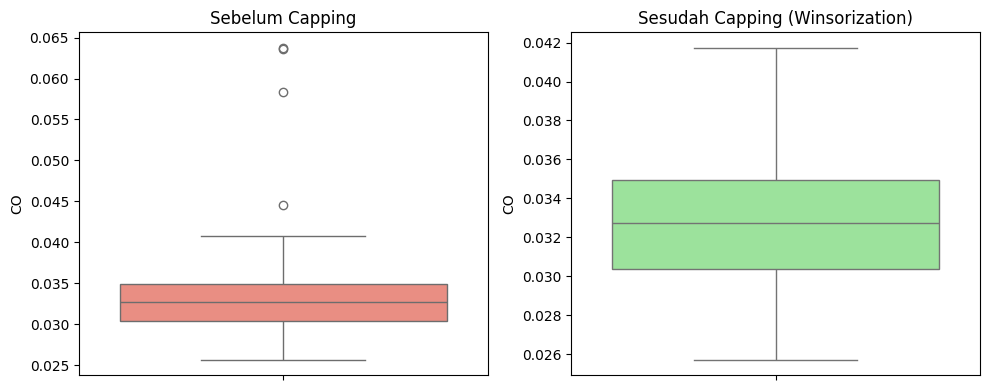

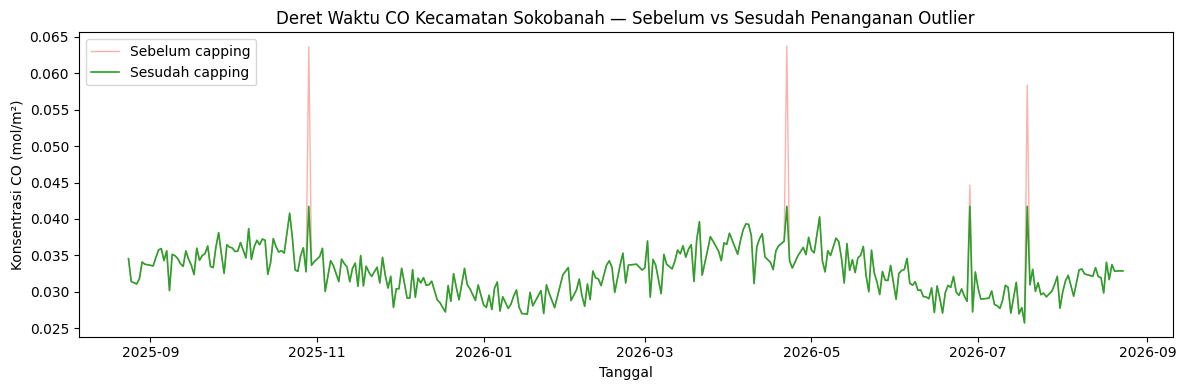

In [8]:
df_final = df_imputed.copy()
df_final[POLUTAN] = df_final[POLUTAN].clip(lower=batas_bawah, upper=batas_atas)

print("Ringkasan statistik SEBELUM capping:")
display(df_imputed[[POLUTAN]].describe())
print("\nRingkasan statistik SESUDAH capping:")
display(df_final[[POLUTAN]].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_imputed[POLUTAN], ax=axes[0], color="salmon")
axes[0].set_title("Sebelum Capping")
sns.boxplot(y=df_final[POLUTAN], ax=axes[1], color="lightgreen")
axes[1].set_title("Sesudah Capping (Winsorization)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_imputed.index, df_imputed[POLUTAN], color="salmon", lw=1, alpha=0.6, label="Sebelum capping")
ax.plot(df_final.index, df_final[POLUTAN], color="tab:green", lw=1.2, label="Sesudah capping")
ax.set_title(f"Deret Waktu CO Kecamatan {KECAMATAN} — Sebelum vs Sesudah Penanganan Outlier")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi CO (mol/m²)")
ax.legend()
plt.tight_layout()
plt.show()


## Langkah 5 — Ekstraksi Fitur TSFEL (365 Hari → 1 Baris Fitur)

TSFEL (*Time Series Feature Extraction Library*) mengubah 365 titik data harian menjadi satu baris berisi puluhan fitur ringkas yang mewakili karakteristik statistik, temporal, dan spektral dari keseluruhan tahun.

- `tsfel.get_features_by_domain()` tanpa argumen mengambil **semua fitur dari 3 domain**: Statistik, Temporal, dan Spektral.
- Setiap kolom hasil ekstraksi diberi nama sesuai format yang diminta: **`[nama_fitur] (fX)`**, dengan `X` = nomor urut fitur (1, 2, 3, ... sampai fitur terakhir).
- Jumlah fitur persis yang dihasilkan bergantung pada versi TSFEL yang terpasang (biasanya berkisar puluhan hingga puluhan lebih, dokumentasi tugas menyebut ±68 fitur) — jumlah pastinya akan tercetak di bawah, dan seluruhnya tetap diberi nomor urut `f1..fN` secara otomatis, tidak dihardcode ke angka 68 agar notebook tidak error jika versi library berbeda.


In [10]:
domain_list = ["statistical", "temporal", "spectral"]


def ekstrak_fitur_tsfel(nilai_array, nama_baris, fs=1):
    """Helper untuk mengekstrak seluruh fitur TSFEL dari satu array nilai
    dan mengembalikan 1 baris DataFrame dengan kolom bernama
    '[nama_fitur] (fX)'. Dipakai baik untuk ekstraksi 1 tahun penuh
    maupun ekstraksi per-kuartal di langkah kemiripan.

    Fitur diekstrak PER DOMAIN (bukan sekaligus 3 domain) untuk
    menghindari bug TSFEL 'cannot reindex on an axis with duplicate
    labels' yang muncul pada sebagian versi library ketika semua
    domain digabung dalam satu konfigurasi.
    """
    nilai_array = np.asarray(nilai_array, dtype=float)

    # jaga-jaga bila window nyaris konstan -> beberapa fitur spektral bisa error
    if np.std(nilai_array) == 0:
        rng = np.random.default_rng(42)
        nilai_array = nilai_array + rng.normal(0, 1e-8, size=len(nilai_array))

    potongan_fitur = []
    for domain in domain_list:
        cfg_domain = tsfel.get_features_by_domain(domain)
        try:
            fitur_domain = tsfel.time_series_features_extractor(
                cfg_domain, nilai_array, fs=fs, verbose=0
            )
        except Exception as e:
            print(f"  -> Domain '{domain}' dilewati karena error: {type(e).__name__}: {e}")
            continue
        # buang kolom duplikat internal (jaga-jaga versi TSFEL lama)
        fitur_domain = fitur_domain.loc[:, ~fitur_domain.columns.duplicated()]
        potongan_fitur.append(fitur_domain)

    if not potongan_fitur:
        raise RuntimeError("Ekstraksi fitur TSFEL gagal total di semua domain.")

    hasil = pd.concat(potongan_fitur, axis=1)
    hasil = hasil.loc[:, ~hasil.columns.duplicated()]  # buang fitur yg muncul di >1 domain
    hasil.columns = [f"{nama_fitur} (f{i + 1})" for i, nama_fitur in enumerate(hasil.columns)]
    hasil.index = [nama_baris]
    return hasil


df_fitur_tahunan = ekstrak_fitur_tsfel(df_final[POLUTAN].values, KECAMATAN)

print(f"Total fitur berhasil diekstraksi: {df_fitur_tahunan.shape[1]} fitur")
print(f"(dari deret waktu {len(df_final)} hari, Kecamatan {KECAMATAN})")
display(df_fitur_tahunan.T.rename(columns={KECAMATAN: "Nilai Fitur"}))

  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
Total fitur berhasil diekstraksi: 45 fitur
(dari deret waktu 365 hari, Kecamatan Sokobanah)


,Nilai Fitur
0_Absolute energy (f1),0.393713
0_Average power (f2),0.001082
0_ECDF Percentile Count_0 (f3),73.000000
0_ECDF Percentile Count_1 (f4),292.000000
0_ECDF Percentile_0 (f5),0.029816
0_ECDF Percentile_1 (f6),0.035520
0_ECDF_0 (f7),0.002740
0_ECDF_1 (f8),0.005479
0_ECDF_2 (f9),0.008219
0_ECDF_3 (f10),0.010959


## Langkah 6 — Analisis Kemiripan Pola CO Antar Kuartal

Notebook sebelumnya mencari kemiripan **antar kecamatan**. Karena sekarang cakupannya dipersempit menjadi **1 kecamatan saja**, perbandingan itu tidak lagi relevan — tidak ada kecamatan lain untuk dibandingkan. Sebagai gantinya, pertanyaan "seberapa mirip" dijawab dengan cara yang tetap bermakna untuk 1 wilayah: **membandingkan pola CO antar 4 periode (kuartal) dalam setahun** di Kecamatan Sokobanah. Ini menjawab pertanyaan seperti: *apakah pola polusi CO di kuartal awal tahun mirip dengan kuartal akhir tahun, atau justru berbeda karena faktor musiman?*

Langkahnya:
1. Data 365 hari dibagi menjadi 4 kuartal (±91 hari per kuartal).
2. Setiap kuartal diekstrak fiturnya secara terpisah dengan fungsi TSFEL yang sama seperti langkah 5, sehingga didapat 4 baris fitur (satu per kuartal).
3. **Cosine similarity** dan **korelasi Pearson** dihitung antar ke-4 vektor fitur tersebut untuk melihat kuartal mana yang polanya paling mirip/berbeda.


  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
  -> Domain 'spectral' dilewati karena error: ValueError: cannot reindex on an axis with duplicate labels
Kolom fitur dibuang karena konstan di semua kuartal: 2 kolom
Kolom fitur dipakai untuk analisis kemiripan: 43 kolom



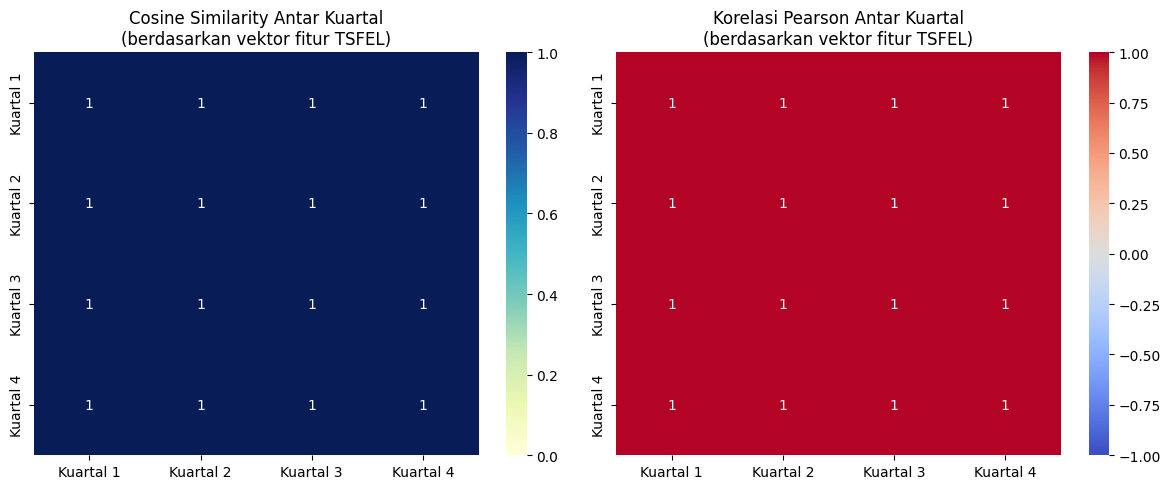

Rata-rata konsentrasi CO per kuartal (mol/m²):
- Kuartal 1: 0.03450
- Kuartal 2: 0.03028
- Kuartal 3: 0.03515
- Kuartal 4: 0.03084


In [11]:
nilai_tahunan = df_final[POLUTAN].values
kuartal_arrays = np.array_split(nilai_tahunan, 4)
nama_kuartal = [f"Kuartal {i + 1}" for i in range(4)]

daftar_fitur_kuartal = [
    ekstrak_fitur_tsfel(arr, nama)
    for arr, nama in zip(kuartal_arrays, nama_kuartal)
]
df_fitur_kuartal = pd.concat(daftar_fitur_kuartal, axis=0)

# buang kolom fitur yang konstan di seluruh kuartal (variansi = 0), karena
# korelasi Pearson tidak terdefinisi (pembagian oleh nol) untuk kolom seperti itu
kolom_konstan = df_fitur_kuartal.columns[df_fitur_kuartal.std(axis=0) == 0]
df_fitur_kuartal_bersih = df_fitur_kuartal.drop(columns=kolom_konstan)
print(f"Kolom fitur dibuang karena konstan di semua kuartal: {len(kolom_konstan)} kolom")
print(f"Kolom fitur dipakai untuk analisis kemiripan: {df_fitur_kuartal_bersih.shape[1]} kolom\n")

# 1. Cosine similarity antar kuartal berdasarkan vektor fitur TSFEL
sim_matrix = cosine_similarity(df_fitur_kuartal_bersih.values)
df_cos_sim = pd.DataFrame(sim_matrix, index=nama_kuartal, columns=nama_kuartal)

# 2. Korelasi Pearson antar kuartal (dihitung dari vektor fitur yang sama)
df_pearson = df_fitur_kuartal_bersih.T.corr(method="pearson")
df_pearson.index = nama_kuartal
df_pearson.columns = nama_kuartal

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(df_cos_sim, annot=True, cmap="YlGnBu", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Cosine Similarity Antar Kuartal\n(berdasarkan vektor fitur TSFEL)")

sns.heatmap(df_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Korelasi Pearson Antar Kuartal\n(berdasarkan vektor fitur TSFEL)")

plt.tight_layout()
plt.show()

print("Rata-rata konsentrasi CO per kuartal (mol/m²):")
for nama, arr in zip(nama_kuartal, kuartal_arrays):
    print(f"- {nama}: {arr.mean():.5f}")


## Langkah 7 — Dokumentasi Lengkap Fitur TSFEL

Bagian ini merangkum **definisi, cara kerja, cara menghitung, rumus, dan makna** dari fitur-fitur utama yang diekstraksi TSFEL, dikelompokkan menurut 3 domain (Statistik, Temporal, Spektral), mengikuti gaya penjelasan pada slide `Ekstraksi_Fitur_TSFEL.pptx`. Fitur-fitur lain yang tidak dibahas satu per satu di sini (misalnya varian FFT-coefficient per indeks, wavelet, atau histogram) mengikuti prinsip domain yang sama dan bisa dicek langsung dari nama kolomnya di `df_fitur_tahunan`.

> Jika ada bagian yang masih belum dipahami setelah membaca dokumentasi ini, silakan dicatat dan ditanyakan pada pertemuan/minggu depan.

---

### 1. Domain Statistik

#### **Mean**
- **Definisi**: Nilai rata-rata konsentrasi CO selama periode yang diamati (365 hari untuk fitur tahunan, ±91 hari untuk fitur per kuartal).
- **Cara Kerja & Menghitung**: Seluruh nilai CO harian dijumlahkan lalu dibagi jumlah observasi $N$.
- **Rumus**: $\mu = \dfrac{1}{N} \sum_{i=1}^{N} x_i$
- **Makna**: Baseline rata-rata paparan polusi CO di kecamatan tersebut pada periode itu.

#### **Variance**
- **Definisi**: Ukuran penyebaran kuadrat data CO di sekitar nilai rata-ratanya.
- **Cara Kerja & Menghitung**: Menghitung kuadrat selisih tiap data harian terhadap mean, lalu dirata-ratakan.
- **Rumus**: $\sigma^2 = \dfrac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$
- **Makna**: Mengukur stabilitas/fluktuasi konsentrasi polutan harian — makin besar, makin fluktuatif.

#### **Standard Deviation**
- **Definisi**: Akar kuadrat varians, mengukur sebaran data dalam satuan asli (bukan kuadrat).
- **Cara Kerja & Menghitung**: Menarik akar kuadrat dari hasil perhitungan varians.
- **Rumus**: $\sigma = \sqrt{\sigma^2}$
- **Makna**: Seberapa jauh kondisi CO harian menyimpang dari rata-rata periode tersebut, dalam satuan yang sama dengan data asli.

#### **Skewness**
- **Definisi**: Ukuran ketidaksimetrisan (kemencengan) distribusi konsentrasi CO.
- **Cara Kerja & Menghitung**: Menghitung momen ketiga terstandardisasi dari data.
- **Rumus**: $\gamma_1 = \dfrac{\frac{1}{N}\sum (x_i-\mu)^3}{\sigma^3}$
- **Makna**: Skewness positif menandakan ada beberapa hari dengan lonjakan polusi ekstrem yang menarik ekor distribusi ke kanan.

#### **Kurtosis**
- **Definisi**: Derajat keruncingan dan ketebalan ekor distribusi data CO.
- **Cara Kerja & Menghitung**: Menghitung momen keempat terstandardisasi.
- **Rumus**: $\beta_2 = \dfrac{\frac{1}{N}\sum (x_i-\mu)^4}{\sigma^4}$
- **Makna**: Kurtosis tinggi berarti variabilitas polusi didominasi lonjakan singkat bernilai ekstrem, bukan fluktuasi merata.

#### **Root Mean Square (RMS)**
- **Definisi**: Akar rata-rata kuadrat dari magnitudo sinyal CO (lihat contoh manual di slide: X=[2,-1,3,-2,4] → RMS ≈ 2.61).
- **Cara Kerja & Menghitung**: Kuadratkan tiap nilai harian → rata-ratakan → tarik akar kuadrat.
- **Rumus**: $x_{rms} = \sqrt{\dfrac{1}{N}\sum_{i=1}^{N} x_i^2}$
- **Makna**: Merepresentasikan besarnya "energi" atau intensitas beban polusi secara keseluruhan pada periode itu.

#### **Interquartile Range (IQR sebagai fitur)**
- **Definisi**: Selisih antara kuartil atas $Q_3$ dan kuartil bawah $Q_1$ dari data pada window tersebut.
- **Cara Kerja & Menghitung**: Urutkan data, tentukan posisi persentil ke-75 dan ke-25, hitung selisihnya.
- **Rumus**: $IQR = Q_3 - Q_1$
- **Makna**: Sebaran 50% data tengah, tidak terpengaruh nilai ekstrem — pelengkap dari IQR yang sudah dipakai di Langkah 3 untuk deteksi outlier.

#### **Absolute Energy**
- **Definisi**: Akumulasi total kuadrat nilai sinyal CO.
- **Cara Kerja & Menghitung**: Jumlahkan kuadrat seluruh nilai CO harian pada window tersebut.
- **Rumus**: $E = \sum_{i=1}^{N} x_i^2$
- **Makna**: Total beban kuantitatif akumulasi CO yang "diterima" lingkungan pada periode tersebut.

#### **Mean Absolute Deviation (MAD, versi statistik)**
- **Definisi**: Rata-rata jarak mutlak setiap data harian terhadap nilai rata-ratanya.
- **Cara Kerja & Menghitung**: Jumlahkan nilai absolut selisih tiap titik terhadap mean, bagi $N$.
- **Rumus**: $MAD = \dfrac{1}{N}\sum_{i=1}^{N} |x_i - \mu|$
- **Makna**: Mengukur variabilitas harian dengan cara yang lebih tahan terhadap outlier dibanding standar deviasi.

#### **ECDF / Quantiles (0.1, 0.25, 0.5, 0.75, 0.9)**
- **Definisi**: Nilai ambang pada persentil tertentu dari fungsi distribusi kumulatif empiris data CO.
- **Cara Kerja & Menghitung**: Urutkan data dari terkecil ke terbesar, ambil titik potong pada persentil terkait.
- **Rumus**: $P(X \le x_p) = p$
- **Makna**: Quantile 0.5 (median) menunjukkan titik tengah polusi; quantile 0.9 menggambarkan kondisi 10% hari terburuk pada periode tersebut.

---

### 2. Domain Temporal

#### **Autocorrelation**
- **Definisi**: Korelasi sinyal CO terhadap dirinya sendiri dengan jeda waktu $k$ hari.
- **Cara Kerja & Menghitung**: Membandingkan deret $x_t$ dengan deret yang sama namun digeser $k$ hari ($x_{t+k}$).
- **Rumus**: $R(k) = \dfrac{\sum_{t=1}^{N-k}(x_t-\mu)(x_{t+k}-\mu)}{\sum_{t=1}^{N}(x_t-\mu)^2}$
- **Makna**: Mengukur "memori" udara — autokorelasi lag-1 tinggi berarti polusi hari ini sangat mirip dengan hari kemarin.

#### **Zero Crossing Rate (ZCR)**
- **Definisi**: Frekuensi deret waktu memotong (melewati) nilai rata-ratanya (lihat contoh manual di slide: X=[2,-1,3,-2,4] → 4 transisi).
- **Cara Kerja & Menghitung**: Menghitung berapa kali terjadi perubahan tanda pada $(x_t - \mu)$.
- **Rumus**: $ZCR = \dfrac{1}{N-1}\sum_{t=1}^{N-1} \mathbb{1}\big[(x_t-\mu)(x_{t+1}-\mu) < 0\big]$
- **Makna**: Menggambarkan seberapa sering kondisi udara berpindah dari "di bawah rata-rata" ke "di atas rata-rata" atau sebaliknya.

#### **Mean Absolute Differences**
- **Definisi**: Rata-rata perubahan mutlak CO dari satu hari ke hari berikutnya (lihat contoh manual di slide: X=[2,-1,3,-2,4] → MAD = 4.5).
- **Cara Kerja & Menghitung**: Jumlahkan nilai mutlak selisih antar hari berturut-turut, bagi $N-1$.
- **Rumus**: $\dfrac{1}{N-1}\sum_{t=1}^{N-1} |x_{t+1}-x_t|$
- **Makna**: Menunjukkan seberapa cepat/volatil perubahan kondisi udara harian.

#### **Peak Detection**
- **Definisi**: Jumlah puncak lokal (local maxima) pada deret waktu.
- **Cara Kerja & Menghitung**: Menghitung titik di mana $x_t > x_{t-1}$ dan $x_t > x_{t+1}$, opsional melebihi ambang tertentu.
- **Makna**: Menunjukkan seberapa sering terjadi lonjakan singkat pencemaran CO pada periode tersebut.

#### **Temporal Centroid**
- **Definisi**: "Pusat gravitasi waktu" dari sinyal CO — kapan (di titik waktu mana) sebagian besar "bobot" konsentrasi terkumpul.
- **Cara Kerja & Menghitung**: Rata-rata tertimbang indeks waktu, dengan bobot = nilai CO itu sendiri.
- **Rumus**: $Centroid = \dfrac{\sum_{t=1}^{N} t \cdot x_t}{\sum_{t=1}^{N} x_t}$
- **Makna**: Menunjukkan pada periode mana (awal/akhir window) konsentrasi CO cenderung lebih terkonsentrasi.

#### **Slope (Linear Trend)**
- **Definisi**: Kemiringan garis lurus hasil regresi linear terhadap deret waktu.
- **Cara Kerja & Menghitung**: Fit garis $y = m \cdot t + c$ dengan metode kuadrat terkecil (least squares).
- **Rumus**: $m = \dfrac{N\sum(t \cdot x_t) - \sum t \sum x_t}{N \sum t^2 - (\sum t)^2}$
- **Makna**: Kemiringan positif ($m>0$) menunjukkan CO cenderung meningkat sepanjang periode tersebut; negatif berarti menurun.

#### **Area Under Curve (AUC)**
- **Definisi**: Luas daerah di bawah kurva grafik deret waktu CO.
- **Cara Kerja & Menghitung**: Aturan integrasi trapesium pada deret waktu.
- **Rumus**: $AUC = \sum_{t=1}^{N-1} \dfrac{x_t + x_{t+1}}{2}$
- **Makna**: Total paparan akumulatif CO sepanjang periode tersebut.

---

### 3. Domain Spektral (berbasis FFT)

Semua fitur di domain ini bekerja dengan cara yang sama: sinyal CO 365 harian pertama-tama ditransformasikan ke domain frekuensi memakai **Fast Fourier Transform (FFT)** — memecah gelombang naik-turun konsentrasi CO yang kompleks menjadi kumpulan gelombang sinus/kosinus sederhana dengan frekuensi & magnitudo berbeda (lihat konsep DFT di slide 14–19).

#### **Spectral Centroid**
- **Definisi**: "Pusat gravitasi" frekuensi dari spektrum sinyal (lihat contoh manual di slide: Magnitudo=[3,1,3,1] → Centroid = 1.25).
- **Cara Kerja & Menghitung**: Transformasi FFT, lalu rata-rata frekuensi tertimbang oleh daya spektralnya.
- **Rumus**: $f_c = \dfrac{\sum f \cdot P(f)}{\sum P(f)}$
- **Makna**: Apakah variasi CO didominasi fluktuasi jangka panjang (frekuensi rendah/musiman) atau perubahan harian yang cepat (frekuensi tinggi).

#### **Spectral Spread**
- **Definisi**: Standar deviasi dari spektrum frekuensi di sekitar spectral centroid (lihat contoh manual di slide: SC=1.25 → Spread ≈ 1.089).
- **Cara Kerja & Menghitung**: Momen kedua spektral terhadap pusat spektrum (mirip varians, tapi di domain frekuensi).
- **Rumus**: $Spread = \sqrt{\dfrac{\sum (f-f_c)^2 P(f)}{\sum P(f)}}$
- **Makna**: Menunjukkan seberapa lebar rentang frekuensi yang berkontribusi pada dinamika emisi CO.

#### **Fundamental Frequency**
- **Definisi**: Frekuensi dasar dengan magnitudo spektral tertinggi.
- **Cara Kerja & Menghitung**: Mengidentifikasi puncak tertinggi pada spektrum daya hasil FFT.
- **Rumus**: $f_0 = \arg\max_f P(f)$
- **Makna**: Mengungkap siklus alami polusi CO yang paling dominan (misalnya siklus mingguan akibat lalu lintas, atau siklus musiman).

#### **Spectral Entropy**
- **Definisi**: Ukuran keacakan distribusi daya frekuensi sinyal CO, mengadopsi entropi Shannon (lihat contoh manual di slide: p=[0.45,0.05,0.45,0.05] → entropi ≈ 1.469 bit).
- **Cara Kerja & Menghitung**: Normalisasi spektrum daya menjadi distribusi probabilitas $p(f)$, lalu hitung entropi Shannon-nya.
- **Rumus**: $H = -\sum p(f)\log_2 p(f)$, dengan $p(f) = \dfrac{P(f)}{\sum P(f)}$
- **Makna**: Entropi tinggi → pola variasi CO kompleks/acak; entropi rendah → ada pola periodik/musiman yang cukup teratur.


## Ringkasan & Catatan Penutup

- Fokus notebook: **1 polutan (CO)**, **1 kecamatan (Sokobanah — data paling lengkap)**.
- Missing values ditangani dengan **interpolasi waktu + ffill/bfill**.
- Outlier dideteksi dengan **IQR** lalu diperbaiki dengan **Winsorization/capping** (bukan dibuang), sehingga jumlah hari tetap 365.
- Fitur diekstraksi dengan **TSFEL (semua domain: statistik, temporal, spektral)** untuk 365 hari penuh, dengan kolom bernama `[nama_fitur] (fX)`.
- Analisis **kemiripan** dialihkan dari "antar kecamatan" menjadi **antar kuartal dalam kecamatan yang sama**, karena cakupan data kini hanya 1 wilayah — tetap memakai cosine similarity & korelasi Pearson seperti semula.
- Dokumentasi definisi/cara kerja/rumus/makna setiap fitur TSFEL ada di Langkah 7.

**Jika ada bagian dari alur ini atau makna suatu fitur yang belum dipahami, catat pertanyaannya dan bisa ditanyakan pada pertemuan minggu depan.**
